<div><center><img src="https://ml.ucv.ai/logo.png" width="150"/> </center></div>

# Asignación #1

## Mineria de Datos [UCV]


* Alumno: Carlos Cao
* Cédula: 28655925
----


Nuestro objetivo en esta asignacion es realizar un preprocesamiento estructural y funcional del dataset "World University Rankings 2023" para garantizar que se cumplan los requerimiento funcionales y estructurales de los datos.

## Carga de Datos y Exploración Inicial

Lo primero que haremos sera importar las librerias necesarias para hacer realizar la visualización y el preprocesamiento de los datos. El dataset se encuentra cargado en mi repositorio de github y de ahi cargaremos los datos. Ademas le haremos una inspección inicial sobre las variables del dataset

In [316]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

URL_DATOS = "https://raw.githubusercontent.com/CaoCarlos55/DM_II_2025/refs/heads/main/Asignaci%C3%B3n%20%231/World%20University%20Rankings%202023.csv"

# Cargamos el dataset
df = pd.read_csv(URL_DATOS)

# Una mirada rápida a los datos
df.head(2341)

,University Rank,Name of University,Location,No of student,No of student per staff,International Student,Female:Male Ratio,OverAll Score,Teaching Score,Research Score,Citations Score,Industry Income Score,International Outlook Score
0,1,University of Oxford,United Kingdom,"20,965",10.6,42%,48 : 52,96.4,92.3,99.7,99.0,74.9,96.2
1,2,Harvard University,United States,"21,887",9.6,25%,50 : 50,95.2,94.8,99.0,99.3,49.5,80.5
2,3,University of Cambridge,United Kingdom,"20,185",11.3,39%,47 : 53,94.8,90.9,99.5,97.0,54.2,95.8
3,3,Stanford University,United States,"16,164",7.1,24%,46 : 54,94.8,94.2,96.7,99.8,65.0,79.8
4,5,Massachusetts Institute of Technology,United States,"11,415",8.2,33%,40 : 60,94.2,90.7,93.6,99.8,90.9,89.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2336,-,University of the West of Scotland,NaN,NaN,NaN,NaN,NaN,34.0–39.2,24.1,15.5,61.5,37.9,76.8
2337,-,University of Windsor,NaN,NaN,NaN,NaN,NaN,34.0–39.2,35.1,29.4,34.5,44.2,88.7
2338,-,University of Wolverhampton,NaN,NaN,NaN,NaN,NaN,34.0–39.2,18.2,14.3,68.8,37.3,72.0
2339,-,University of Wuppertal,NaN,NaN,NaN,NaN,NaN,34.0–39.2,26.4,26.7,52.8,52.1,47.6


A simple vista podemos observar un dato compuesto que seria `Female: Male Ratio`, que contiene el porcentaje de cada genero en la universidad. Tambien podemos ver rangos de valores e incluso valores nulos en el dataset, pero al parecer se concentran al final del dataset.

Para analizarlo mas a profundidad, veremos los tipos de datos y la cantidad de datos no nulo.

In [317]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2341 entries, 0 to 2340
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   University Rank              2341 non-null   object 
 1   Name of University           2233 non-null   object 
 2   Location                     2047 non-null   object 
 3   No of student                2209 non-null   object 
 4   No of student per staff      2208 non-null   float64
 5   International Student        2209 non-null   object 
 6   Female:Male Ratio            2128 non-null   object 
 7   OverAll Score                1799 non-null   object 
 8   Teaching Score               1799 non-null   float64
 9   Research Score               1799 non-null   float64
 10  Citations Score              1799 non-null   float64
 11  Industry Income Score        1799 non-null   float64
 12  International Outlook Score  1799 non-null   float64
dtypes: float64(6), obj

Podemos observar columnas como `No of student`, `International Student`, `Female:Male Ratio` y `OverAll Score` aparecen como `Object`, algo contradictorio porque las variables representan valores numericos. Esta presencia impide realizar comparaciones estadisticas, por lo que es necesario hacer una conversión a tipos de datos numericos.

### Visualizando datos incompletos

Antes de empezar a limpiar y organizar los datos, primero le echaremos un vistazo para ver cuantos valores nulos existen en el dataset y como estan distribuido.

In [318]:
# Cálculo exacto del porcentaje de nulos por columna
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
df_status = pd.DataFrame({'Nulos': missing_data, 'Porcentaje (%)': missing_percent})
print("Resumen de Vacíos por Variable:")
print(df_status[df_status['Nulos'] > 0].sort_values(by='Nulos', ascending=False))

Resumen de Vacíos por Variable:
                             Nulos  Porcentaje (%)
Research Score                 542       23.152499
Citations Score                542       23.152499
OverAll Score                  542       23.152499
Teaching Score                 542       23.152499
Industry Income Score          542       23.152499
International Outlook Score    542       23.152499
Location                       294       12.558736
Female:Male Ratio              213        9.098676
No of student per staff        133        5.681333
No of student                  132        5.638616
International Student          132        5.638616
Name of University             108        4.613413


Podemos observar que la mayoria de los datos nulos se encuentran en los puntajes contando todos con un 23% de datos vacíos. A diferencia de los otras variables, que tienen un 12% o menos.

Para visualizar de mejor manera como estos datos nulos estan distruibuido en el dataset, utilizaremos un mapa de calor.

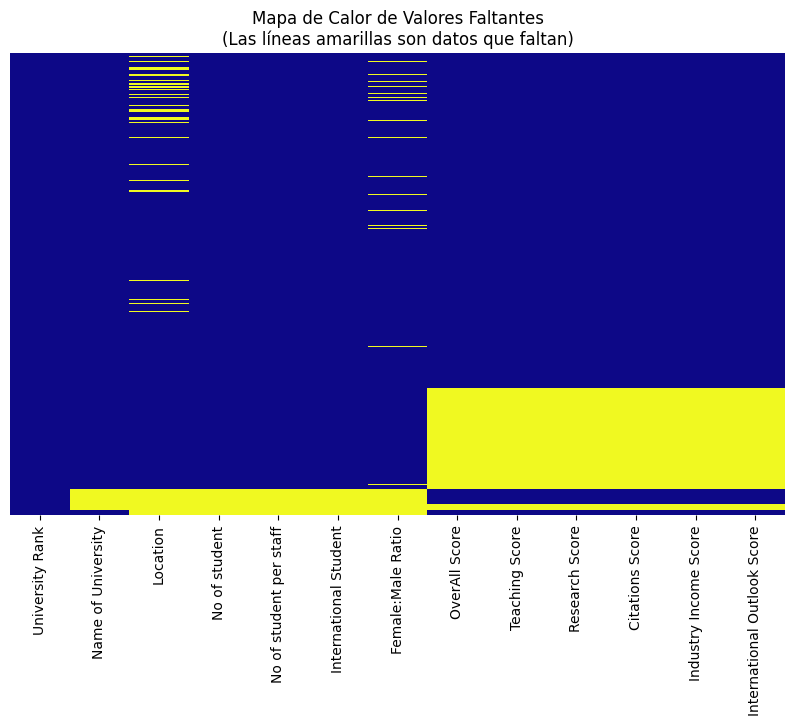

In [319]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='plasma')
plt.title("Mapa de Calor de Valores Faltantes\n(Las líneas amarillas son datos que faltan)")
plt.show()

Con esta grafica podemos observar de mejor manera como estan distribuidos los valores nulos, viendo que existen dos huecos en el dataset, el primero se encuentra en los puntajes de las universidades y el otro grupo son datos descriptivo y poblacionales, ambos huecos se encuentran casi al final del ranking. Esto probablemente suceda porque son universidades que no calcularon sus puntuaciones o estan esperando a ser revisados.

Tambien algunas universidades carecen de datos especificos como su ubicación y ratio de genero.

## Transformación estructural

En esta etapa, nos enfocamos en modificar la estructura del dataset para facilitar su manipulación y asegurar que cumplan con los requisitos estructurales.

### Estandarización de variables

Primeros modificaremos los nombres de la variable para que sigan un estandar, debido a que las columnas originales suelen contener espacios, mayúsculas mixtas y caracteres especiales que dificultan el acceso a los datos y pueden generar errores de sintaxis en algunos metodos. Para esto, seguiremos el estandar snake_scase, es decir, palabras en minuscula dividido por el caracter de piso.

In [320]:
df.columns = [col.strip().lower().replace(' ', '_').replace(':', '_') for col in df.columns]

# Mostramos los nuevos nombres
print("Nuevos nombres de las columnas:")
print(df.columns.tolist())

Nuevos nombres de las columnas:
['university_rank', 'name_of_university', 'location', 'no_of_student', 'no_of_student_per_staff', 'international_student', 'female_male_ratio', 'overall_score', 'teaching_score', 'research_score', 'citations_score', 'industry_income_score', 'international_outlook_score']


### Tratamiento de Datos Compuestos

Anteriormente habiamos detectado que `Female:Male Ratio` es una variable de tipo compuesta, conteniendo dos valores que serian el porcentaje de mujeres y hombres en una sola cadena de texto.

La transformación se realizara dividiendo la columna compuesta en dos columnas que representen los porcentajes de cada genero, ademas de convertirlos en datos numericos.

In [321]:
# Dividiendo la columna compuesta
posicion = df.columns.get_loc('female_male_ratio')
temp_ratios = df['female_male_ratio'].str.split(' : ', expand=True).apply(pd.to_numeric, errors='coerce')

# Esto se hizo para insertar las nuevas columnas en el lugar de la columna original
df.insert(posicion, 'female_percent', temp_ratios[0])
df.insert(posicion + 1, 'male_percent', temp_ratios[1])

# Eliminando la columna original por ser redundante
df.drop(columns=['female_male_ratio'], inplace=True)

df.head()

,university_rank,name_of_university,location,no_of_student,no_of_student_per_staff,international_student,female_percent,male_percent,overall_score,teaching_score,research_score,citations_score,industry_income_score,international_outlook_score
0,1,University of Oxford,United Kingdom,"20,965",10.6,42%,48.0,52.0,96.4,92.3,99.7,99.0,74.9,96.2
1,2,Harvard University,United States,"21,887",9.6,25%,50.0,50.0,95.2,94.8,99.0,99.3,49.5,80.5
2,3,University of Cambridge,United Kingdom,"20,185",11.3,39%,47.0,53.0,94.8,90.9,99.5,97.0,54.2,95.8
3,3,Stanford University,United States,"16,164",7.1,24%,46.0,54.0,94.8,94.2,96.7,99.8,65.0,79.8
4,5,Massachusetts Institute of Technology,United States,"11,415",8.2,33%,40.0,60.0,94.2,90.7,93.6,99.8,90.9,89.3


El resultado de la transformación es que la columna original es eliminada y sustituida por `female_percent` y `male_percent`, mejorando la legibilidad del dataset y permitiendo realizar comparaciones entre estudiantes del mismo genero de las diferentes universidades.

## Tranformaciones funcionales

Despues de haber definido la representación correcta del dataset, ahora nos centramos en las transformaciones de los datos para mejorar su usabilidad mediante distintas tecnicas.

### Conversión a columnas numéricas

Como habiamos mencionado anteriormente, hay muchas variables representadas como texto, esto sucede porque tienen simbolos como la coma y el porcentaje, entonces vamos a eliminar estos caracteres y transformarlo a un valor numerico. Sin esta transformación, seria complicado hacer un analisis sobre la cantidad de estudiantes nacionales e internacionales debido a la dificultad de las comparaciones.

#### Numero de estudiantes

En el caso de numero de estudiantes, utilizaba la coma como un separador de valores grandes. Entonces la transformación sera eliminar esas comas.

In [322]:
df['no_of_student'] = df['no_of_student'].astype(str).str.replace(',', '')
df['no_of_student'] = pd.to_numeric(df['no_of_student'], errors='coerce')

#### Estudiantes internacionales

A diferencia del anterior, estudiantes internacionales utilizaba el simbolo de porcentaje para indicar cuanto de su población es estudiantes internacional, entonces la transfomación sera eliminar el simbolo %.



In [323]:
df['international_student'] = df['international_student'].astype(str).str.replace('%', '')
df['international_student'] = pd.to_numeric(df['international_student'], errors='coerce')
df.rename(columns={'international_student': 'international_student_percent'}, inplace=True)

Despues de la transfomación, tambien se modifico el nombre de la columna para evitar confusiones, sin esto se podria entender que solo pueden tener hasta 100 estudiantes internacionales.

In [324]:
# Verificamos los cambios
print("Nuevos tipos de datos:")
print(df[['no_of_student', 'international_student_percent']].dtypes)

Nuevos tipos de datos:
no_of_student                    float64
international_student_percent    float64
dtype: object


Despues de la transformaciones podemos observar que cada variable cumple con el tipo de dato correspondiente.

### Manejo de rangos

Un problema que se presenta en la columna `Overall Score` es que a partir del top 201 las puntuaciones estan agrupadas en rangos especificos. Por esa razón, esta variable es almacenada como texto, dificultando cualquier operación estadistica. Sucede lo mismo con la variable de `University Rank`, puesto que los puntajes generales son rangos, implica que el ranking tambien lo sería.

Para la transfomarción de `Overall Score`, utilizamos una estrategia de normalización que tomar el valor representativo como el punto medio del rango. Para esto sumamos el limite superior e inferior y lo dividimos entre 2. Este resultado lo guardamos en una columna temporal para verificar si la transformación se hizo bien, comparandolo con la columna original.

En el caso de ranking, tomaremos el limite inferior como el valor representante. Pero este problema lo solucionaremos al final, cuando arreglemos los puntajes, asi podemos definir el ranking de las universidades que no han sido reportado.

In [325]:
# Prepraramos la columna
scores = df['overall_score'].astype(str)

# Dividimos los rangos y convertimos a numérico
split_scores = scores.str.split('–', expand=True).apply(pd.to_numeric, errors='coerce')

# Calculamos el promedio entre las columnas resultantes
df.insert(
    df.columns.get_loc('overall_score'),
    'overall_score_clean',
    split_scores.mean(axis=1)
)
print("Ejemplos de transformación en Overall Score:")
print(df[['overall_score', 'overall_score_clean']].iloc[950:1050])

Ejemplos de transformación en Overall Score:
     overall_score  overall_score_clean
950      29.8–33.9                31.85
951      29.8–33.9                31.85
952      29.8–33.9                31.85
953      29.8–33.9                31.85
954      29.8–33.9                31.85
...            ...                  ...
1045     24.4–29.7                27.05
1046     24.4–29.7                27.05
1047     24.4–29.7                27.05
1048     24.4–29.7                27.05
1049     24.4–29.7                27.05

[100 rows x 2 columns]


Como podemos ver ahora todas esas puntuaciones que estaban en un rango tomaran el valor del punto medio.

Cabe destacar que los valores nulos de la columna seguiran nulos, porque solo aplicamos una transformación a los intervalos.

Ahora procederemos a eliminar la columna original, dejando la nueva columna con los datos normalizados.

In [326]:
df.drop(columns=['overall_score'], inplace=True)
df.tail()

,university_rank,name_of_university,location,no_of_student,no_of_student_per_staff,international_student_percent,female_percent,male_percent,overall_score_clean,teaching_score,research_score,citations_score,industry_income_score,international_outlook_score
2336,-,University of the West of Scotland,NaN,NaN,NaN,NaN,NaN,NaN,36.6,24.1,15.5,61.5,37.9,76.8
2337,-,University of Windsor,NaN,NaN,NaN,NaN,NaN,NaN,36.6,35.1,29.4,34.5,44.2,88.7
2338,-,University of Wolverhampton,NaN,NaN,NaN,NaN,NaN,NaN,36.6,18.2,14.3,68.8,37.3,72.0
2339,-,University of Wuppertal,NaN,NaN,NaN,NaN,NaN,NaN,36.6,26.4,26.7,52.8,52.1,47.6
2340,-,Xi’an Jiaotong-Liverpool University,NaN,NaN,NaN,NaN,NaN,NaN,36.6,17.8,14.8,68.2,38.2,72.4


Para confirmar que la transformación se hizo en toda la columna revisamos la cola del dataset, ademas tambien verificamos que se elimino la columna `Overall Score`.

### Tratamiento de valores faltantes

Continuando con las transformaciones funcionales, trataremos los valores nulos o faltante de las observaciones. Como habiamos visto previamente habian varios huecos en distinta parte del dataset, para cada uno aplicaremos una tecnica diferente.

#### Nombre de la universidad y Locación incompleta

En el caso de analisis sobre universidades en el mundo, las variables como `Name of University` y `Location` toman mucha importancia al ser datos de identidad, no se pueden inventar o promediar.

Por ejemplo, una universidad sin nombre puede tener puntajes muy buenos o malos, pero si no sabemos de quien habla, no podemos atribuirle los resultados a algo. Sucede lo mismo con la locación, si queremos estudiar una región para saber si esta mejorando o empeorando su educación, seria imposible con la falta de este dato.

Debido a esto, se tomo la decisión de eliminar estos datos incompletos para mejorar la confianza de cualquier analisis que se le quiera hacer.

In [327]:
print("Valores nulos antes de la eliminación:")
print(df[['name_of_university', 'location']].isnull().sum())

# Eliminamos las observaciones vacias de locación y universidad
df.dropna(subset=['name_of_university'], inplace=True)
df.dropna(subset=['location'], inplace=True)

print("\nValores nulos despues de la eliminación:")
print(df[['name_of_university', 'location']].isnull().sum())

Valores nulos antes de la eliminación:
name_of_university    108
location              294
dtype: int64

Valores nulos despues de la eliminación:
name_of_university    0
location              0
dtype: int64


#### Genero incompleto

En el caso de los valores nulos de cada genero, hay que aplicar una inserción a uno de los generos (en este caso femenino) y posteriormente, se calcula el porcentaje del genero contrario como el complemento, para garantizar que la proporción este bien, es decir, que sume el 100%. La imputación que se le aplicara sera tomar la mediana de todo la columna, para que se no sea afectada por valores extremos.



In [328]:
print("Valores nulos antes de la imputación:")
print(df[['female_percent', 'male_percent']].isnull().sum())

# Aplicamos la imputación por la mediana
media_female = df['female_percent'].median()
df['female_percent'] = df['female_percent'].fillna(media_female)
df['male_percent'] = df['male_percent'].fillna(100 - media_female)

print("\nValores nulos después de la imputación:")
print(df[['female_percent', 'male_percent']].isnull().sum())

Valores nulos antes de la imputación:
female_percent    63
male_percent      63
dtype: int64

Valores nulos después de la imputación:
female_percent    0
male_percent      0
dtype: int64


Despues de la transformación, vamos a verificar si todos los datos de cada genero esten bien.

In [329]:
check = (df['male_percent'] + df['female_percent'] == 100).all()
print(f"¿Todos los registros suman exactamente 100?: {check}")

¿Todos los registros suman exactamente 100?: True


#### Puntajes incompletos

Para concluir el preprocesamiento, realizaremos una imputación por muestreo aleatorio sobre las columnas de puntajes. A diferencia de la mediana, este enfoque garantiza que no todas las universidades sin puntaje posean exacetamente el mismo rendimiento, permitiendo que los valores imputados sigan el comportamiento observado en el resto de las universidades y evitando sesgos por centralidad debido a la mediana.

In [330]:
print("Valores nulos antes de la imputación:")
print(df[['overall_score_clean','teaching_score', 'research_score','citations_score','industry_income_score', 'international_outlook_score']].isnull().sum())

# Aplicamos la imputación por muestreo aleatorio
cols_to_impute = [
    'overall_score_clean', 'teaching_score', 'research_score',
    'citations_score', 'industry_income_score', 'international_outlook_score'
]

for col in cols_to_impute:
    # Identificamos dónde están los nulos
    null_mask = df[col].isnull()
    num_nulls = null_mask.sum()

    if num_nulls > 0:
        # Tomamos una muestra aleatoria de los valores que SÍ existen
        random_samples = df[col].dropna().sample(num_nulls, replace=True, random_state=28655925).values

        df.loc[null_mask, col] = random_samples

print("\nValores nulos después de la imputación:")
print(df[['overall_score_clean','teaching_score', 'research_score','citations_score','industry_income_score', 'international_outlook_score']].isnull().sum())

Valores nulos antes de la imputación:
overall_score_clean            501
teaching_score                 501
research_score                 501
citations_score                501
industry_income_score          501
international_outlook_score    501
dtype: int64

Valores nulos después de la imputación:
overall_score_clean            0
teaching_score                 0
research_score                 0
citations_score                0
industry_income_score          0
international_outlook_score    0
dtype: int64


### Solución del Ranking

Como ya hemos solucionado el tema del puntaje, podemos ordernar el ranking de acuerdo a ello.

In [331]:
def actualizar_ranking(dataframe, columna_score='overall_score_clean'):
    # Ordenamos el Datasetde mayor a menor puntaje
    dataframe = dataframe.sort_values(by=columna_score, ascending=False).reset_index(drop=True)

    # Usamos method='min' para que los empates tengan el mismo puesto
    dataframe['university_rank'] = dataframe[columna_score].rank(method='min', ascending=False).astype(int)

    return dataframe

df = actualizar_ranking(df)

print(df[['university_rank', 'name_of_university', 'overall_score_clean']].head(10))

   university_rank                     name_of_university  overall_score_clean
0                1                   University of Oxford                 96.4
1                1             Samarkand State University                 96.4
2                3           Silesian University in Opava                 95.2
3                3                     Harvard University                 95.2
4                5                    Stanford University                 94.8
5                5                University of Cambridge                 94.8
6                7  Massachusetts Institute of Technology                 94.2
7                8     California Institute of Technology                 94.1
8                9                   Princeton University                 92.4
9               10     University of California, Berkeley                 92.1


Como recalculamos el ranking basándonos únicamente en el `overall_score_clean`, el ranking resultante muestra a universidades como "Samarkand State University" o "Silesian University in Opava" en los puestos 1 y 3 respectivamente, esto se debe a la imputación por muestreo aleatario, ya que se colocaron valores sin distinguir la región o promedio, esto para simplicidad del ejercicio. Aunque con una imputación condicionada podría ser mas precisa.

Despues de realizar todas las transformaciones funcionales necesarias, vamos a verificar si nos quedan datos nulos en alguna columna que no trabajamos.

In [332]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2047 entries, 0 to 2046
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   university_rank                2047 non-null   int64  
 1   name_of_university             2047 non-null   object 
 2   location                       2047 non-null   object 
 3   no_of_student                  2047 non-null   float64
 4   no_of_student_per_staff        2046 non-null   float64
 5   international_student_percent  2044 non-null   float64
 6   female_percent                 2047 non-null   float64
 7   male_percent                   2047 non-null   float64
 8   overall_score_clean            2047 non-null   float64
 9   teaching_score                 2047 non-null   float64
 10  research_score                 2047 non-null   float64
 11  citations_score                2047 non-null   float64
 12  industry_income_score          2047 non-null   f

Como podemos observar faltan algunos valores en dos columnas, pero lo solucionaremos imputando la mediana al ser poco los valores que faltan.

In [333]:
df['international_student_percent'] = df['international_student_percent'].fillna(df['international_student_percent'].median())
df['no_of_student_per_staff'] = df['no_of_student_per_staff'].fillna(df['no_of_student_per_staff'].median())

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2047 entries, 0 to 2046
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   university_rank                2047 non-null   int64  
 1   name_of_university             2047 non-null   object 
 2   location                       2047 non-null   object 
 3   no_of_student                  2047 non-null   float64
 4   no_of_student_per_staff        2047 non-null   float64
 5   international_student_percent  2047 non-null   float64
 6   female_percent                 2047 non-null   float64
 7   male_percent                   2047 non-null   float64
 8   overall_score_clean            2047 non-null   float64
 9   teaching_score                 2047 non-null   float64
 10  research_score                 2047 non-null   float64
 11  citations_score                2047 non-null   float64
 12  industry_income_score          2047 non-null   f

好! (bien!), se termino la transformaciones necesaria para que el dataset cumpla con los requisitos estructurales y funcionales.

## Resultado del dataset preprocesado

Vamos a revisar el dataset preprocesado en distintas partes para verificar que los datos esten bien.

### Primeras 50 filas

In [334]:
df.head(50)

,university_rank,name_of_university,location,no_of_student,no_of_student_per_staff,international_student_percent,female_percent,male_percent,overall_score_clean,teaching_score,research_score,citations_score,industry_income_score,international_outlook_score
0,1,University of Oxford,United Kingdom,20965.0,10.6,42.0,48.0,52.0,96.4,92.3,99.7,99.0,74.9,96.2
1,1,Samarkand State University,Uzbekistan,15754.0,17.2,0.0,50.0,50.0,96.4,92.3,99.7,99.0,74.9,96.2
2,3,Silesian University in Opava,Czech Republic,5322.0,20.4,6.0,71.0,29.0,95.2,94.8,99.0,99.3,49.5,80.5
3,3,Harvard University,United States,21887.0,9.6,25.0,50.0,50.0,95.2,94.8,99.0,99.3,49.5,80.5
4,5,Stanford University,United States,16164.0,7.1,24.0,46.0,54.0,94.8,94.2,96.7,99.8,65.0,79.8
5,5,University of Cambridge,United Kingdom,20185.0,11.3,39.0,47.0,53.0,94.8,90.9,99.5,97.0,54.2,95.8
6,7,Massachusetts Institute of Technology,United States,11415.0,8.2,33.0,40.0,60.0,94.2,90.7,93.6,99.8,90.9,89.3
7,8,California Institute of Technology,United States,2237.0,6.2,34.0,37.0,63.0,94.1,90.9,97.0,97.3,89.8,83.6
8,9,Princeton University,United States,8279.0,8.0,23.0,46.0,54.0,92.4,87.6,95.9,99.1,66.0,80.3
9,10,"University of California, Berkeley",United States,40921.0,18.4,24.0,52.0,48.0,92.1,86.4,95.8,99.0,76.8,78.4


### Filas 500-550

In [335]:
df.iloc[500:550]

,university_rank,name_of_university,location,no_of_student,no_of_student_per_staff,international_student_percent,female_percent,male_percent,overall_score_clean,teaching_score,research_score,citations_score,industry_income_score,international_outlook_score
500,402,Stranmillis University College,United Kingdom,1060.0,23.6,18.0,79.0,21.0,43.50,39.1,39.2,46.2,48.9,54.7
501,402,United International University,Bangladesh,4632.0,21.4,1.0,30.0,70.0,43.50,36.0,30.1,64.1,36.9,53.9
502,402,Syracuse University,United States,20620.0,14.9,23.0,52.0,48.0,43.50,34.9,28.0,64.3,37.2,50.7
503,402,Universiti Teknologi Petronas,Malaysia,5021.0,13.6,16.0,38.0,62.0,43.50,26.8,33.8,58.9,77.6,76.7
504,402,Tianjin University,China,27353.0,8.7,12.0,53.0,47.0,43.50,35.3,42.8,51.6,89.9,41.5
505,402,University of Trento,Italy,14219.0,19.2,8.0,52.0,48.0,43.50,27.0,32.3,66.5,41.1,56.9
506,402,The University of Tulsa,United States,4407.0,12.0,10.0,48.0,52.0,43.50,37.8,17.1,75.6,48.0,36.4
507,402,University of Turin,Italy,58463.0,28.4,6.0,61.0,39.0,43.50,21.5,29.7,77.5,43.9,41.4
508,402,TU Wien,Austria,10327.0,17.7,31.0,31.0,69.0,43.50,40.1,37.4,38.1,62.0,87.6
509,402,Umeå University,Sweden,18218.0,12.6,11.0,61.0,39.0,43.50,21.9,29.6,78.4,38.5,64.5


### Filas 1500-1550

In [336]:
df.iloc[1500:1550]

,university_rank,name_of_university,location,no_of_student,no_of_student_per_staff,international_student_percent,female_percent,male_percent,overall_score_clean,teaching_score,research_score,citations_score,industry_income_score,international_outlook_score
1500,1363,National University of Distance Education (UNED),Spain,66141.0,56.9,5.0,54.0,46.0,21.35,17.8,18.5,21.9,38.2,29.5
1501,1363,National Chung Hsing University,Taiwan,15150.0,16.8,7.0,41.0,59.0,21.35,21.5,21.0,17.2,51.3,31.8
1502,1363,National Chin-Yi University of Technology,Taiwan,7294.0,23.2,5.0,30.0,70.0,21.35,15.2,23.6,13.6,46.4,24.1
1503,1363,National Chengchi University,Taiwan,12489.0,14.8,13.0,57.0,43.0,21.35,23.9,28.3,11.0,44.4,47.6
1504,1363,Nagoya City University,Japan,4514.0,7.5,4.0,48.0,52.0,21.35,24.5,15.8,24.1,51.2,21.7
1505,1363,Nagasaki University,Japan,8869.0,6.7,6.0,39.0,61.0,21.35,24.2,13.0,22.1,43.9,36.1
1506,1363,Nagaoka University of Technology,Japan,2189.0,11.1,12.0,10.0,90.0,21.35,25.0,15.7,9.1,47.3,36.5
1507,1363,University of Mysore,India,7970.0,21.4,10.0,42.0,58.0,21.35,31.3,8.6,20.8,37.3,34.5
1508,1363,University of Mumbai,India,13330.0,23.5,1.0,51.0,49.0,21.35,29.6,19.9,16.1,38.0,16.7
1509,1363,Multimedia University,Malaysia,7116.0,10.6,11.0,51.0,49.0,21.35,19.5,10.7,25.6,38.5,42.1


### Ultimas 50 filas

In [337]:
df.tail(50)

,university_rank,name_of_university,location,no_of_student,no_of_student_per_staff,international_student_percent,female_percent,male_percent,overall_score_clean,teaching_score,research_score,citations_score,industry_income_score,international_outlook_score
1997,1717,Meiji University,Japan,33090.0,34.2,5.0,35.0,65.0,14.35,17.0,11.4,6.6,41.3,27.4
1998,1717,Medical University of Silesia in Katowice,Poland,10267.0,7.6,5.0,74.0,26.0,14.35,22.8,9.1,18.5,39.0,23.0
1999,1717,Instituto Politécnico Nacional (IPN),Mexico,133839.0,12.6,0.0,42.0,58.0,14.35,18.4,10.6,12.5,43.0,25.2
2000,1717,Inönü University,Turkey,30348.0,19.2,2.0,36.0,64.0,14.35,24.6,8.4,15.5,36.9,17.6
2001,1717,Universidad Industrial de Santander (UIS),Colombia,20708.0,13.8,1.0,45.0,55.0,14.35,16.1,10.1,7.9,43.6,35.2
2002,1717,Ibaraki University,Japan,7863.0,14.8,3.0,35.0,65.0,14.35,17.5,12.2,6.9,42.1,24.2
2003,1717,University of Hyogo,Japan,6592.0,12.7,3.0,42.0,58.0,14.35,17.9,12.3,4.7,47.3,21.3
2004,1717,Hue University,Vietnam,47590.0,22.0,1.0,57.0,43.0,14.35,13.7,8.1,14.5,37.4,47.2
2005,1717,Hellenic Open University,Greece,19311.0,6.8,1.0,61.0,39.0,14.35,19.8,8.1,23.0,37.0,23.4
2006,1717,University of Havana,Cuba,15002.0,8.6,4.0,63.0,37.0,14.35,23.3,11.3,7.9,42.4,51.0


## Usos del dataset preprocesado

Despues de tener el dataset preprocesado, tenemos dos caminos disponibles para continuar con el analisis. En primer lugar, podemos dejar los datos preprocesados como estan, debido a que ya esta trabajado para mejorar su interpretación, lo que facilita la realización de un analisis exploratorio de los datos. Esto se debe a que priorizamos la legibilidad de la información, conservando los nombres, las categorias y las escalas originales de los puntajes permitiendo que cualquier persona pueda interpretar las tendencias y anomalías de forma directa.

Por otro lado, si tomamos el camino orientado a los modelos de aprendizaje. Tendriamos que continuar preprocesando los datos, debido a que es necesario llevar la información a una estructura mas facil de procesar para el computador. Aquí, el computador sacrifica el sentido de los datos en favor de una representación numerica, esto se hace mediante tecnicas de entandarización y normalización enfocadas en numeros, de esta manera realiza calculos precisos sin tener que comprender el lenguaje humano.